# Análisis Exploratorio de Datos (EDA) - Dataset de Ataques Cardíacos

## Introducción

Este notebook presenta un análisis exploratorio completo del dataset de ataques cardíacos. El objetivo es comprender los patrones, relaciones y características de los datos que permitan predecir la presencia de enfermedad cardíaca.

### Dataset
El dataset contiene 303 registros con 14 variables relacionadas con la salud cardiovascular:

**Variables:**
- `age`: Edad del paciente
- `sex`: Sexo (1 = masculino, 0 = femenino)
- `cp`: Tipo de dolor torácico (0-3)
- `trestbps`: Presión arterial en reposo (mm Hg)
- `chol`: Colesterol sérico (mg/dl)
- `fbs`: Glucemia en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
- `restecg`: Resultados electrocardiográficos en reposo (0-2)
- `thalach`: Frecuencia cardíaca máxima alcanzada
- `exang`: Angina inducida por ejercicio (1 = sí, 0 = no)
- `oldpeak`: Depresión del ST inducida por ejercicio
- `slope`: Pendiente del segmento ST en ejercicio pico (0-2)
- `ca`: Número de vasos principales coloreados por fluoroscopía (0-4)
- `thal`: Talasemia (0 = normal, 1 = defecto fijo, 2 = defecto reversible, 3 = no especificado)
- `target`: Presencia de enfermedad cardíaca (1 = sí, 0 = no)

### Objetivos del EDA
1. Comprender la distribución de variables
2. Identificar valores atípicos y valores faltantes
3. Analizar correlaciones entre variables
4. Explorar relaciones con la variable objetivo
5. Preparar insights para modelado predictivo

# 1. Importacion de librerias

In [24]:
# Librerias de visualizacion y manipulacion de datos
import pandas as pd 
import numpy as np
# Visualizacion
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_style('whitegrid') 
# Estadistica
from scipy import stats
from scipy.stats import shapiro



# 2. Carga y exploracion inicial de los datos.


In [25]:

# Ruta del data frame
df = pd.read_csv("../data/raw/HeartAttackDataSet.csv")

# Dimenciones del data frame 
print(f"=" * 80)
print(f"Dimensiones del data frame: {df.shape[0]} numero de filas y {df.shape[1]} numero de columnas ")
# Información del data frame
print(f"=" * 80)
print (f"Tipos de datos del data frame")
print(f"=" * 80)

Dimensiones del data frame: 303 numero de filas y 14 numero de columnas 
Tipos de datos del data frame


In [26]:
# Primeras 5 filas del data frame
print(f"Primeras 5 filas del data frame")
df.head()
# Validacion de tipos de datos del data frame 

Primeras 5 filas del data frame


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# 3. Analisis de calidad de datos.
### 3.1 Analisis de datos faltantes (nulos)
- La integridad de los datos previene sesgos algoritmicos, al tratarse de un modelo orientado a la salud, tenemos que tener la mejor calidad de datos posibles.

In [27]:
# Valores nulos.
print(f"=" *80)
nulos = df.isnull().sum()
print(f"total de nulos: ")
display(nulos)

total de nulos: 


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**Fundamentación**: La ausencia de valores nulos es fundamental en medicina predictiva. Una historia clínica incompleta en un modelo algorítmico podría derivar en sesgos peligrosos. 

### 3.2 Analisis de valores duplicados
**Fundamentacion**: Una cantidad considerable de duplicados podria alterar los resultados del modelo de machine learning.

In [28]:
# Deteccion de valores duplicados
duplicates = df.duplicated().sum()
print(f"Total de valores duplicados: {duplicates}")
print("=" * 80)
print(f"Porcentaje de duplicados en el data set: {(duplicates/len(df)*100):.2f} %")
print("Duplicados encontrados: ")
print("=" * 80)
display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))

Total de valores duplicados: 1
Porcentaje de duplicados en el data set: 0.33 %
Duplicados encontrados: 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [29]:
# Eliminar duplicado
df.drop_duplicates()
print(f"Valores duplicados despues de limpieza: {df.duplicated().sum()}")

Valores duplicados despues de limpieza: 1


**Fundamentacion**: La limpieza de duplicados asegura que no estemos sobreestimando el riesgo basado en registros repetidos de un mismo evento clínico.

# 4. Estadisticas descriptivas y target
### 4.1 Analisis de la variable objetivo (target) 
Fundamentacion: En problemas de clasificacion un desbalance de clases podria invalidar la metrica accuracy

In [30]:
# Muestro estadisticas descriptiva la cual nos proporciona un resumen de los datos como media, desviación, etc.
numeric_stats = df.describe().T
numeric_stats['cv'] = numeric_stats['std'] / numeric_stats['mean'] * 100 # coeficiente de variación
numeric_stats['range'] = numeric_stats['max'] - numeric_stats['min']
numeric_stats['iqr'] = numeric_stats['75%'] - numeric_stats['25%']

# Interpretacion de coeficiente de variacion
print(f"="*80)
display(numeric_stats)
print(f"="* 80)
print(f"Interpretación de coeficiente de variacion: ")
print(f"="*80)
print(f"CV < 15%: Baja variabilidad")
print(f"CV 15% - 35%: Variabilidad moderada")
print(f"CV > 35%: Alta variabilidad")
high_var = numeric_stats[numeric_stats['cv'] > 35]['cv'].sort_values(ascending=False)
for i, cv in high_var.items():
    print(f"- {i}: {cv:.2f}%")
print("Total de variables con CV alto > 35%: ", high_var.value_counts().sum())

,count,mean,std,min,25%,50%,75%,max,cv,range,iqr
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0,16.705376,48.0,13.5
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0,68.213178,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0,106.727612,3.0,2.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0,13.324450,106.0,20.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0,21.046822,438.0,63.5
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0,239.839902,1.0,0.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0,99.584661,2.0,1.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0,15.306142,131.0,32.5
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0,143.785579,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2,111.684359,6.2,1.6


Interpretación de coeficiente de variacion: 
CV < 15%: Baja variabilidad
CV 15% - 35%: Variabilidad moderada
CV > 35%: Alta variabilidad
- fbs: 239.84%
- exang: 143.79%
- ca: 140.20%
- oldpeak: 111.68%
- cp: 106.73%
- restecg: 99.58%
- target: 91.60%
- sex: 68.21%
- slope: 44.04%
Total de variables con CV alto > 35%:  9


- **Capa Técnica**: El Coeficiente de Variación (CV) revela una dispersión extrema en variables como fbs (239.8%), exang (143.7%) y ca (140.2%). Variables críticas como age y trestbps (presión arterial) muestran una variabilidad baja (<17%), lo que indica una muestra relativamente homogénea en términos demográficos y de presión basal.

- **Capa de Dominio**: El CV del 239% en fbs (glucemia en ayunas) sugiere que la gran mayoría de los pacientes tienen niveles normales, y solo una minoría presenta hiperglucemia, lo cual es típico en datasets de cribado general no específicos para diabetes.

- **Capa de "Puntos Ciegos"**: La variable oldpeak (depresión del segmento ST) tiene un CV del 111%. Esto suele ser un indicador muy fuerte de isquemia, pero al estar tan sesgado, un modelo lineal podría tener dificultades para capturar su impacto si no se trata su distribución.

### 4.2. Distribucion de variable objetivo


,Clase,Frecuencia,Porcentaje
target,,,
1,Sin enfermedad (0),165,54.455446
0,Con enfermedad (1),138,45.544554


Data set balanceado: 0.84


C:\Users\asjer\AppData\Local\Temp\ipykernel_22732\1642187091.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='target', palette='viridis')


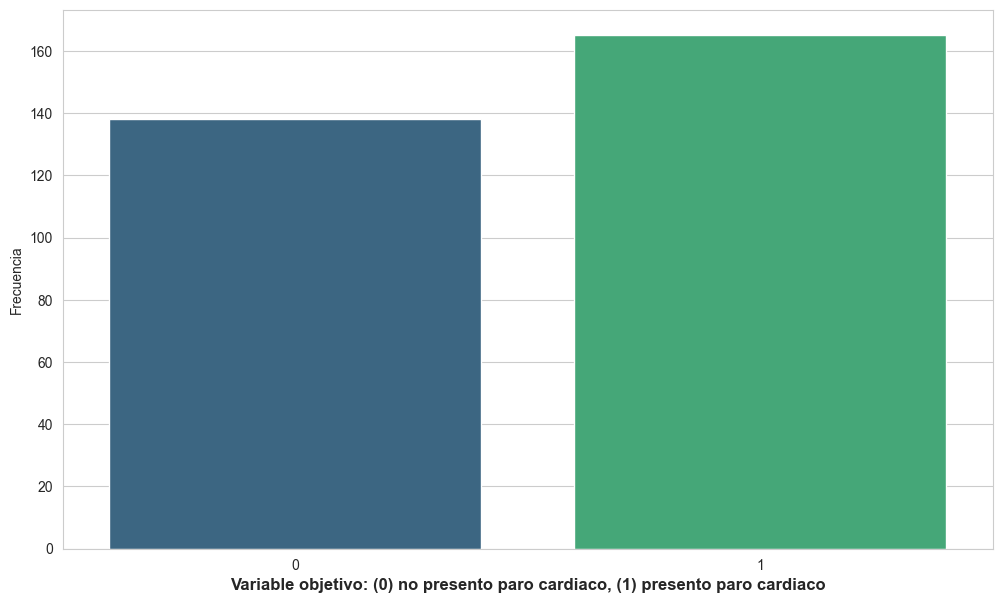

In [31]:
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({
    'Clase': ['Sin enfermedad (0)', 'Con enfermedad (1)'],
    'Frecuencia': target_counts.values,
    'Porcentaje': target_pct
})
display(target_summary)

# Balance ratio
balance_ratio = target_counts.min() / target_counts.max()
if balance_ratio > 0.8:
    print(f"Data set balanceado: {balance_ratio:.2f}")
elif balance_ratio  > 0.5:
    print(f"Data set moderadamente balanceado: {balance_ratio:.2f}")
else:
    print("Data set desbalanceado < 0.5 % ")

# Visualizacion de la variable objetivo.
plt.figure(figsize=(12,7))
sns.countplot(df, x='target', palette='viridis')
plt.xlabel('Variable objetivo: (0) no presento paro cardiaco, (1) presento paro cardiaco', fontsize='12', fontweight='bold')
plt.ylabel('Frecuencia')
plt.show()

A simple vista podemos detectar un data set bastante balanceado, es decir, que la proporción de datos de paro cardiaco es similar a la proporción de datos de no paro cardiaco.

- **Capa Técnica**: La muestra está balanceada: 54.4% "Sin enfermedad" vs 45.5% "Con enfermedad". El Balance Ratio de 0.836 es excelente para entrenamiento de modelos.

- **Capa de Dominio**: En un entorno clínico real, encontrar un 45% de prevalencia es inusual (salvo en unidades de cuidados intensivos o cardiología especializada). Esto confirma que el dataset proviene de una población con sospecha clínica previa, no de un chequeo general de población sana.

- **Capa de "Puntos Ciegos"**: Aunque el balance ayuda al entrenamiento, el modelo final podría sobreestimar el riesgo si se aplica a la población general (Falsos Positivos), debido a esta alta prevalencia artificial en la muestra.

# 5. Analisis de distribuciones
### 5.1 Test de normalidad:
**Fundamentacion**: Muchos algoritmos de Machine Learning asumen normalidad en los datos, el teste de Shapiro-Wilk es más potentes que otros test para la detectar desviaciones de la normalidad de los datos.

In [32]:
def test_normality(df, columns):
    """
    Realiza el test de normalidad de Shapiro-Wilk para cada columna.
    H0: Los datos siguen una distribucion normal
    Si p-value  < 0.05 se descarta H0 y se asume que los datos siguen una distribucion anormal 
    """
    results = [] # lista vacia donde se almacenaran los calculos del test
    for col in columns:
        stats, p_value = shapiro(df[col].dropna())
        results.append({
            'Variable': col,
            'Statistic': stats,
            'P-value': p_value,
            'Normal': 'Si' if p_value > 0.05 else 'No'
        })
    return pd.DataFrame(results)
print(f"=" *80)
print(f"Test de normalidad Shapiro-Wilk")
print(f"=" *80)
print(f"H0: Los datos siguen una normalidad normal")
print(f"Si p-value > 0.05")
numerical_cols = df.select_dtypes(include=[np.number])
normality_results = test_normality(df, numerical_cols).round(3)

display(normality_results)

normal_vars = normality_results[normality_results['Normal'] == 'Si']['Variable'].tolist()
nonormal_vars = normality_results[normality_results['Normal'] == 'No']['Variable'].tolist()
print(f"Variables con distribucion normal: {len(normal_vars)}")
print(f"Variables con distribucion no normal: {len(nonormal_vars)}")

Test de normalidad Shapiro-Wilk
H0: Los datos siguen una normalidad normal
Si p-value > 0.05


,Variable,Statistic,P-value,Normal
0,age,0.986,0.006,No
1,sex,0.586,0.000,No
2,cp,0.790,0.000,No
3,trestbps,0.966,0.000,No
4,chol,0.947,0.000,No
5,fbs,0.424,0.000,No
6,restecg,0.679,0.000,No
7,thalach,0.976,0.000,No
8,exang,0.591,0.000,No
9,oldpeak,0.844,0.000,No


Variables con distribucion normal: 0
Variables con distribucion no normal: 14


- **Capa Técnica**: Todas las variables (14/14) tienen un p-value de 0.000, rechazando la hipótesis nula de normalidad.

- **Capa de Dominio**: Los indicadores biológicos como el colesterol o la frecuencia cardíaca máxima en pacientes cardíacos suelen presentar sesgos (cola derecha para colesterol, cola izquierda para frecuencia máxima).

- **Capa de "Puntos Ciegos":** Normalmente se suele aplicar modelos de Regresión Logística asumiendo normalidad. Aquí, el uso de modelos basados en árboles (Random Forest, XGBoost) o la aplicación de transformaciones (Box-Cox/Log) es obligatorio para mejorar la convergencia de modelos paramétricos.

### 5.2 Visualizacion de distribuciones
**Fundamentacion**: Los histogramas con curvas KDE y boxplots nos permiten identificar:
- Forma de la distribucion: (Simetrica, sesgada)
- Precencia de multiplies modas.
- Valores atipicos (outliers).
- Rango y dispersion de datos.

In [33]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


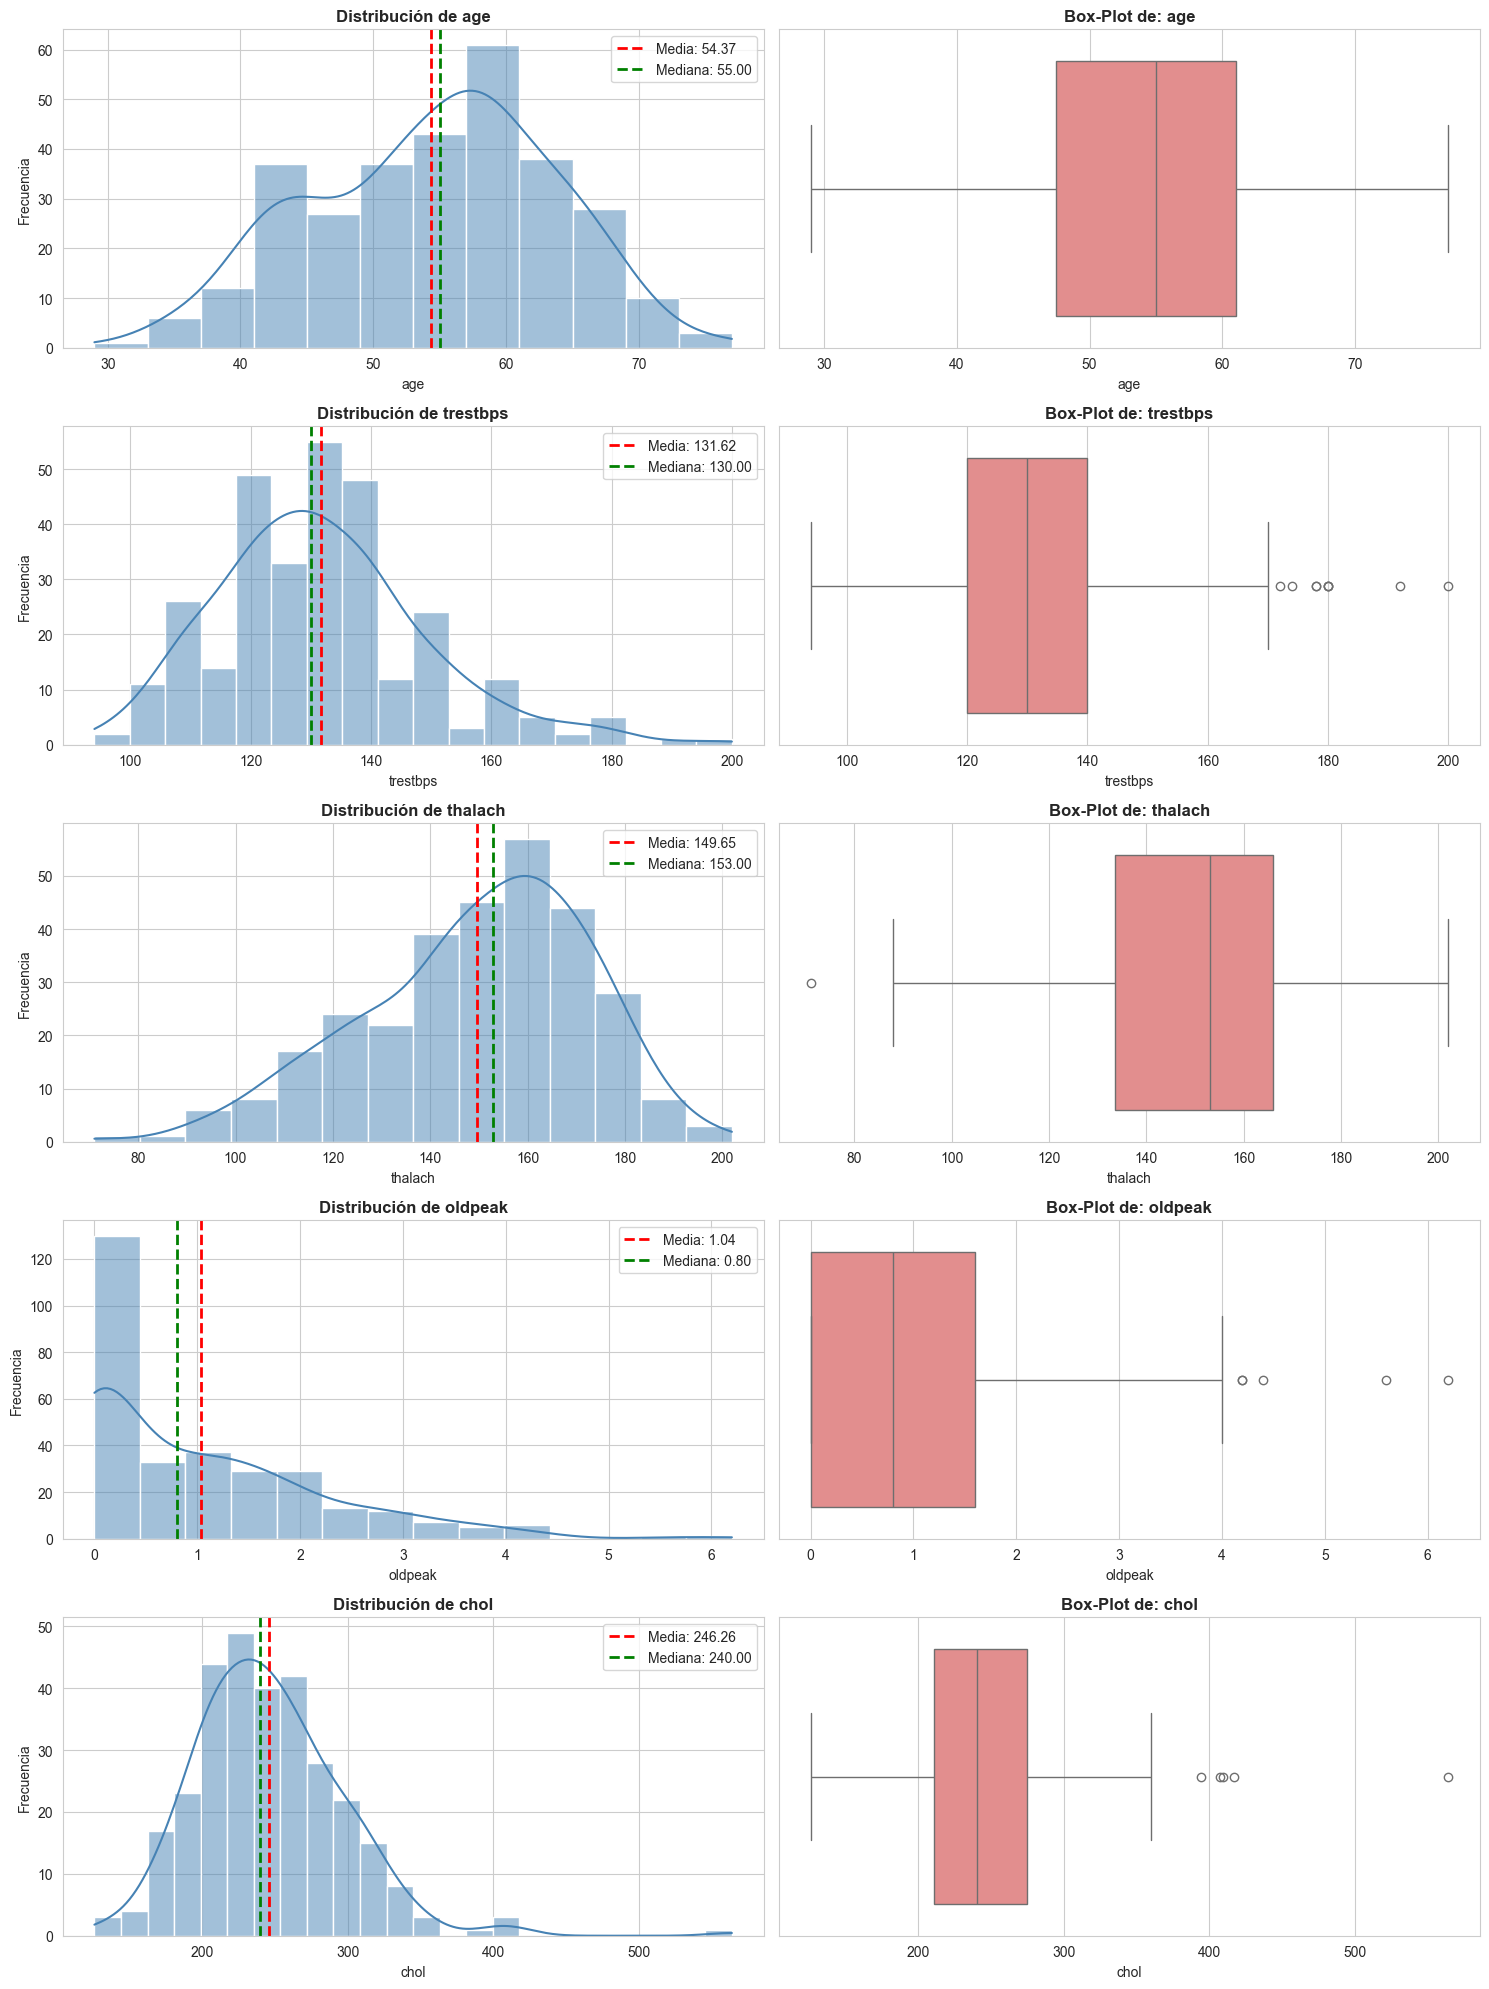

In [34]:
# Seleccionar variables continuas, seleccionamos aquellas que tengan numero continuo.

continuous_var = ['age', 'trestbps','thalach','oldpeak','chol']

fig, axes = plt.subplots(len(continuous_var), 2, figsize=(15, 4*len(continuous_var)))

for idx, col in enumerate(continuous_var):
    # Histograma con curva KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx, 0], color='steelblue')
    axes[idx, 0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col, fontsize=10)
    axes[idx, 0].set_ylabel('Frecuencia', fontsize=10)
    # Lineas de media y mediana
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx, 0].axvline(mean_val, color='red', linestyle="--", linewidth=2, label=f"Media: {mean_val:.2f}")
    axes[idx, 0].axvline(median_val, color='green', linestyle="--", linewidth=2, label=f"Mediana: {median_val:.2f}")
    axes[idx, 0].legend()
    # Boxplots
    sns.boxplot(data=df, x=col, color="lightcoral", ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Box-Plot de: {col}", fontsize='12', fontweight='bold')
plt.tight_layout()
plt.show()

- **Capa Técnica:** Se observan valores atípicos significativos en chol (colesterol > 500 mg/dl) y trestbps (presión arterial > 190 mm Hg).

- **Capa de Dominio:** En cardiología, un "outlier" no suele ser un error de medición, sino el paciente de mayor riesgo. Un colesterol de 564 mg/dl es un caso de hipercolesterolemia familiar severa y es el dato más valioso para el modelo.

- **Capa de "Puntos Ciegos":** Eliminar estos valores por "limpieza estadística" sería un error clínico fatal, ya que estaríamos eliminando precisamente los casos más críticos que el modelo debe aprender a detectar.

# 5.2 Distribuciones por categoria objetivo
**Fundamentacion**: Comparar distribuciones de variables discriminantes que separan bien las clases positivias y negativas

C:\Users\asjer\AppData\Local\Temp\ipykernel_22732\578329562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y=col, palette='Set2', ax=axes[idx], split=True)
C:\Users\asjer\AppData\Local\Temp\ipykernel_22732\578329562.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No', 'Si'])
C:\Users\asjer\AppData\Local\Temp\ipykernel_22732\578329562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y=col, palette='Set2', ax=axes[idx], split=True)
C:\Users\asjer\AppData\Local\Temp\ipykernel_22732\578329562.py:9: UserWarning: set_ticklabel

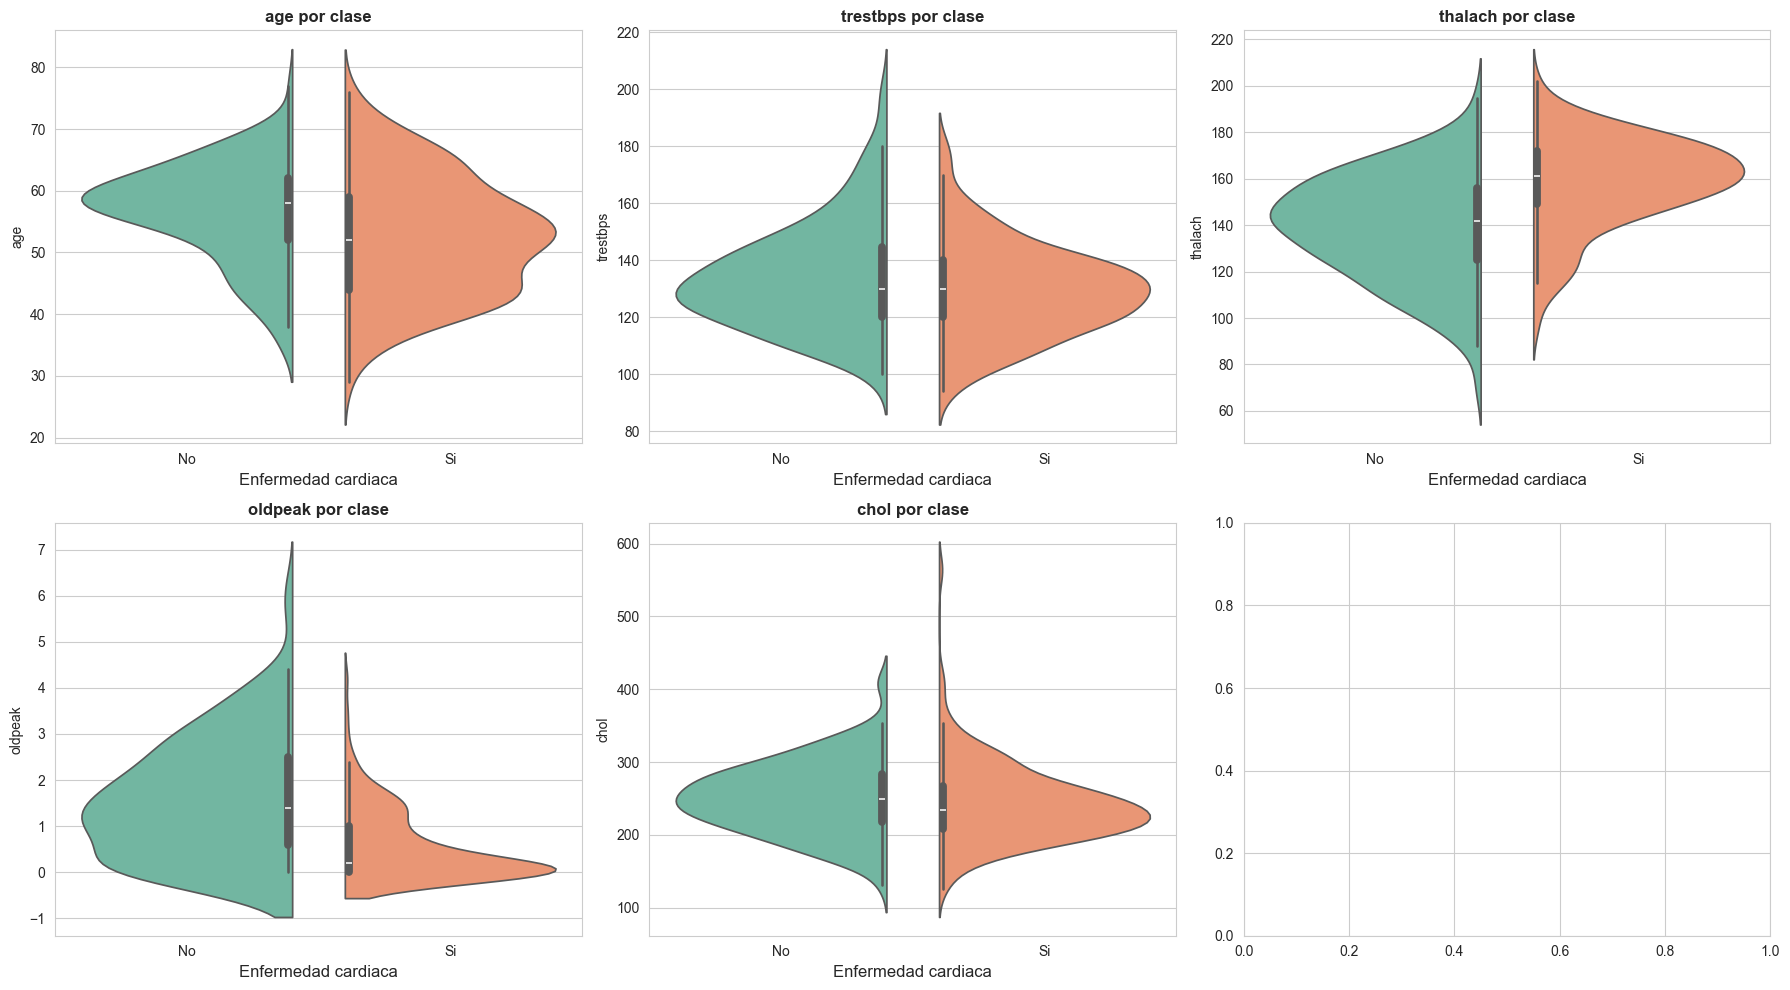

In [35]:
fig, axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.ravel() # 
# Grafico violinplot
for idx, col in enumerate(continuous_var):
    sns.violinplot(data=df, x='target', y=col, palette='Set2', ax=axes[idx], split=True)
    axes[idx].set_title(f"{col} por clase", fontsize='12', fontweight='bold')
    axes[idx].set_xlabel('Enfermedad cardiaca', fontsize='12')
    axes[idx].set_ylabel(col, fontsize='10')
    axes[idx].set_xticklabels(['No', 'Si'])
plt.tight_layout()
plt.show()

# 6. Deteccion de Valores Átipicos (Outliers)
### 6.1 Metodo IQR (Rango intercuartilico)
**Fundamentacion**: El metodo IQR define valores outliers que van mas alla de:
- Q1 - 1.5 x IQR (Limite inferior)
- Q3 + 1.5 x IQR (Limite superior)

In [36]:
def detect_outliers_iqr(df, columns):
    """
    Detecta valores atipicos usando el metodo IQR
    """
    outliers_summary = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outliers_summary.append({
            'Variable': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_bound': lower_bound,
            'Upper_bound': upper_bound,
            'Num_outliers': len(outliers),
            'Outliers_pct': len(outliers) / len(df) * 100
        })
    return pd.DataFrame(outliers_summary)
outliers_analysis = detect_outliers_iqr(df, continuous_var)
display(outliers_analysis)
print(f"=" * 80)
print(f"Total de variables con outliers: {len(outliers_analysis)}")
print(f"=" * 80)
total_outliers = outliers_analysis['Num_outliers'].sum()
print(f"Total de outliers encontrados: {total_outliers}")
print(f"=" * 80)
print(f"Variables con mas outliers: ")
top_outliers = outliers_analysis.nlargest(3, 'Num_outliers')[['Variable', 'Num_outliers','Outliers_pct']]
display(top_outliers)



,Variable,Q1,Q3,IQR,Lower_bound,Upper_bound,Num_outliers,Outliers_pct
0,age,47.5,61.0,13.5,27.25,81.25,0,0.000000
1,trestbps,120.0,140.0,20.0,90.00,170.00,9,2.970297
2,thalach,133.5,166.0,32.5,84.75,214.75,1,0.330033
3,oldpeak,0.0,1.6,1.6,-2.40,4.00,5,1.650165
4,chol,211.0,274.5,63.5,115.75,369.75,5,1.650165


Total de variables con outliers: 5
Total de outliers encontrados: 20
Variables con mas outliers: 


,Variable,Num_outliers,Outliers_pct
1,trestbps,9,2.970297
3,oldpeak,5,1.650165
4,chol,5,1.650165


**Intepretacion**: 
- Capa Técnica: Se observan valores atípicos significativos en chol (colesterol > 500 mg/dl) y trestbps (presión arterial > 190 mm Hg), con el metodo IQR se puede obtener una numero maximo de outliers de 369 mg/dl, lo que indica claramente colesterol alto, pero sin sesgar tanto el modelo, lo que poduciria mejor resultado, lo mismo para trestbps con un maximo de 170 mm/ hg.

- Capa de Dominio: En cardiología, un "outlier" no suele ser un error de medición, sino el paciente de mayor riesgo. Un colesterol de 564 mg/dl es un caso de hipercolesterolemia familiar severa y es el dato más valioso para el modelo.

- Capa de "Puntos Ciegos": Eliminar estos valores por "limpieza estadística" sería un error clínico fatal, ya que estaríamos eliminando precisamente los casos más críticos que el modelo debe aprender a detectar.

### 6.2 Z-Score Metodo
**Fundamentacion**: Los Z- Scores miden cuantas desviaciones estandar se esta un valor de la media, Z > 3 se consideran outliers extremos. Este metodo asume normalidad.

In [37]:
def detect_outliers_zscore (df, col, threshold=3):
    """
    Detecta outliers aplicando el metodo z-score
    """
    outlier_summary = []
    for col in col:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = df[col][z_scores > threshold]

        outlier_summary.append({
            'Variable': col,
            'Mean': df[col].mean(),
            'Std': df[col].std(),
            'Outliers': len(outliers),
            'Outlier_pct': (len(outliers) / len(df)) * 100
        })
    return pd.DataFrame(outlier_summary)
zscore_outliers = detect_outliers_zscore(df, continuous_var)
display(zscore_outliers)

,Variable,Mean,Std,Outliers,Outlier_pct
0,age,54.366337,9.082101,0,0.000000
1,trestbps,131.623762,17.538143,2,0.660066
2,thalach,149.646865,22.905161,1,0.330033
3,oldpeak,1.039604,1.161075,2,0.660066
4,chol,246.264026,51.830751,4,1.320132
